# Clase 11
## Web scrapping

In [42]:
#!pip install lxml

import cloudscraper
import lxml
import requests 
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt
import pandas as pd

El **web scraping** es una técnica utilizada para extraer información de páginas web. 

Para acceder a una página web desde Python, es necesario realizar una solicitud (request) al servidor.

## Librería requests

Lo más báscio para utilizar es la librería **requests**, que permite enviar solicitudes a través del protocolo HTTPS y obtener el contenido de una página. 

El comando **get()** es el que vamos a usar para traer la información de una página. Cada vez que ejecutamos el comando get estamos enviando una consulta al servidor. Hay que ser responsables en el uso de las consultas ya que si se ejecutan demasiadas pueden generar problemas en el servidor o incluso pueden bloquear nuestra IP por uso indebido.


### Observatorio de noticias


Vamos a trabajar con los titulares de noticias en Pagina 12

Primero, usamos requests.get para hacer la consulta

In [43]:
a = requests.get("https://www.pagina12.com.ar/")

In [44]:
a.status_code

200

In [45]:
a.content

b'<!DOCTYPE html><html lang="es" dir="ltr"><head><meta name="viewport" content="width=device-width, initial-scale=1"/><link rel="icon" href="/pf/resources/favicon-v3.ico?d=67&amp;mxId=00000000"/><link rel="apple-touch-icon" sizes="180x180" href="/pf/resources/favicon/180X180.png?d=67&amp;mxId=00000000"/><link rel="icon" type="image/png" sizes="32x32" href="/pf/resources/favicon/32X32.png?d=67&amp;mxId=00000000"/><link rel="icon" type="image/png" sizes="16x16" href="/pf/resources/favicon/16X16.png?d=67&amp;mxId=00000000"/><link rel="icon" type="image/png" sizes="192x192" href="/pf/resources/favicon/192X192.png?d=67&amp;mxId=00000000"/><title>P\xc3\xa1gina | 12: La otra mirada sobre Argentina y el mundo</title><meta property="og:title" content="P\xc3\xa1gina|12"/><meta name="twitter:title" content="P\xc3\xa1gina|12"/><meta property="og:image" content="https://www.pagina12.com.ar/resizer/v2/https%3A%2F%2Fwww.pagina12.com.ar%2Fresources%2Fp12logo.svg?auth=811d0fc63a912d1f8dc56b650f3a0054e0

### Beautiful Soup

Para poder leer bien lo que hay adentro de nuestro request, vamos a tener que usar otra librería muy conocida llamada BeautifulSoup. Es una librería con un montón de cosas, pero NO vamos a profundizar mucho hoy.

In [46]:
#!pip install BeautifulSoup4
from bs4 import BeautifulSoup

Con **BeautifulSoup()** vamos a poder parsear nuestro contenido a un html hecho y derecho.

In [47]:
soup = BeautifulSoup(a.content, 'html.parser')
soup

<!DOCTYPE html>
<html dir="ltr" lang="es"><head><meta content="width=device-width, initial-scale=1" name="viewport"/><link href="/pf/resources/favicon-v3.ico?d=67&amp;mxId=00000000" rel="icon"/><link href="/pf/resources/favicon/180X180.png?d=67&amp;mxId=00000000" rel="apple-touch-icon" sizes="180x180"/><link href="/pf/resources/favicon/32X32.png?d=67&amp;mxId=00000000" rel="icon" sizes="32x32" type="image/png"/><link href="/pf/resources/favicon/16X16.png?d=67&amp;mxId=00000000" rel="icon" sizes="16x16" type="image/png"/><link href="/pf/resources/favicon/192X192.png?d=67&amp;mxId=00000000" rel="icon" sizes="192x192" type="image/png"/><title>Página | 12: La otra mirada sobre Argentina y el mundo</title><meta content="Página|12" property="og:title"/><meta content="Página|12" name="twitter:title"/><meta content="https://www.pagina12.com.ar/resizer/v2/https%3A%2F%2Fwww.pagina12.com.ar%2Fresources%2Fp12logo.svg?auth=811d0fc63a912d1f8dc56b650f3a0054e089ac9c81bfee069a62717e10cbb54a&amp;width=1

Lo que nos va a interesar ahora para tratar de identificar los titulares de Pagina12 es usar **soup.find_all("h2)** para buscar todos los titulares que esten a nivel h2

In [48]:
titulos = soup.find_all('h2')
titulos

[<h2 class="p12Heading h2 title" style="font-weight:700">La Fiscalía venezolana revocó la excarcelación del opositor Juan Pablo Guanipa</h2>,
 <h2 class="p12Heading h2 title" style="font-weight:700">El carnaval es tiempo de unión con la comunidad afro en Concordia</h2>,
 <h2 class="p12Heading h2 title" style="font-weight:700">El último que cierre la puerta: festival de renuncias y despidos en el Gobierno</h2>,
 <h2 class="p12Heading h2 title" style="font-weight:700">Acosado por denuncias de corrupción, renunció Demian Reidel</h2>,
 <h2 class="p12Heading h2 title" style="font-weight:700">La abogada argentina detenida en Brasil se reunió con el cónsul argentino en Río de Janeiro</h2>,
 <h2 class="p12Heading h2 title" style="font-weight:700">Ley de Inocencia Fiscal: la nueva obsesión del Gobierno por los “dólares del colchón”</h2>,
 <h2 class="p12Heading h2 title" style="font-weight:700">Spagnuolo, de los audios al procesamiento</h2>,
 <h2 class="p12Heading h2 title" style="font-weight:70

Para dejarlo lindo, podríamos usar get_text(), también de BeautifulSoup para extraer el texto dentro de cada headline

In [49]:
only_titles = [h2.get_text(strip=True) for h2 in titulos]
only_titles

['La Fiscalía venezolana revocó la excarcelación del opositor Juan Pablo Guanipa',
 'El carnaval es tiempo de unión con la comunidad afro en Concordia',
 'El último que cierre la puerta: festival de renuncias y despidos en el Gobierno',
 'Acosado por denuncias de corrupción, renunció Demian Reidel',
 'La abogada argentina detenida en Brasil se reunió con el cónsul argentino en Río de Janeiro',
 'Ley de Inocencia Fiscal: la nueva obsesión del Gobierno por los “dólares del colchón”',
 'Spagnuolo, de los audios al procesamiento',
 'Derecho, poder y verdad en disputa',
 'Un show que recordó que América es todo un continente y no solo EE. UU.',
 'Donald Trump, en llamas contra el show de Bad Bunny en el Super Bowl',
 'Quién es Juan Martín Campos, el hombre que llega a Nucleoeléctrica después de Reidel',
 'Demian Reidel no pasará a la historia, pero si lo hace será por un exabrupto',
 'Roberto Gustavo Lescano De Cicco, Juan Enrique Reggiardo',
 '“Un gran vendedor de humo”: lo que Demian Reid

### Ejercicio 1.
Identificar la incidencia de los siguientes tópicos dentro de los titulares de noticias: "reforma laboral", "Trump", "Bad Bunny", "inflación", "dólar".

¿Hay noticias ccon estos temas? ¿Cuánto aparece cada una? ¿Hay algún tema que aparezca más?

In [50]:
topicos = ["reforma laboral", "Trump", "Bad Bunny", "inflación", "dólar"]

for topico in topicos:
    titulos = [title for title in only_titles if topico in title]
    print(topico, titulos)
    print()

reforma laboral ['Santilli confía en que el Gobierno conseguirá la media sanción de la reforma laboral']

Trump ['Donald Trump, en llamas contra el show de Bad Bunny en el Super Bowl']

Bad Bunny ['Donald Trump, en llamas contra el show de Bad Bunny en el Super Bowl', 'Bad Bunny llevó la fiesta caribeña al corazón del imperio', 'Ricky Martin, Lady Gaga, Pedro Pascal y los famosos que respaldaron a Bad Bunny']

inflación ['Se acelera la suba de precios: la inflación en CABA fue de 3,1% en enero']

dólar ['Ley de Inocencia Fiscal: la nueva obsesión del Gobierno por los “dólares del colchón”', 'Milei reglamentó su blanqueo permanente para los “dólares del colchón”']



#### Ejercicio 2. 
Implementar una función que, al pasarle una portal de noticias y un tema, te devuelva los titulares.

In [51]:
def titulares(url, tema):
    a = requests.get(url)
    soup = BeautifulSoup(a.content, 'html.parser')
    titulos = soup.find_all('h2')
    only_titles = [h2.get_text(strip=True) for h2 in titulos]
    titulos_de_tema = [title for title in only_titles if tema.lower() in title.lower()]
    return titulos_de_tema

In [52]:
titulares("https://www.pagina12.com.ar/", "reforma laboral")

['Santilli confía en que el Gobierno conseguirá la media sanción de la reforma laboral']

In [53]:
titulares("https://www.infobae.com/", "reforma laboral")

['Reforma laboral: mañana se reunirá la mesa política y el Gobierno ya les avisó a las provincias que se eliminará Ganancias',
 'Bullrich se reúne con los dialoguistas en el Senado para definir el articulado final de la reforma laboral',
 'Un gobernador reveló “amenazas” para que los peronistas no aprueben la reforma laboral en el Congreso']

### Scrapeando con Pandas

Pandas tiene la función **read_html** que nos permite extraer tablas de cualquier página web. En este caso, vamos a chusmear la página **fbref.com** que tiene estadísticas futboleras. Nos interesa descargar algunas tablas de la Primera División de Argentina.

In [54]:
url = "https://fbref.com/en/comps/21/2025/2025-Liga-Profesional-Argentina-Stats"


response = requests.get(url)

response


<Response [403]>

In [55]:
url = "https://es.wikipedia.org/wiki/Campeonato_de_Primera_Divisi%C3%B3n_2025_(Argentina)"
headers = {'User-Agent': 'Mozilla/5.0'}

tabla = pd.read_html(url, storage_options=headers)

tabla

[   Liga Profesional 2025 Primera División de Argentina  \
                                        Datos generales   
 0                                                Sede    
 1                                          Asociación    
 2                                     Fecha de inicio    
 3                                     Fecha de cierre    
 4                                             Edición    
 5                                    N.º de ediciones    
 6                                         Organizador    
 7                                          TV oficial    
 8                                            Palmarés    
 9                                             Campeón    
 10                                 Datos estadísticos    
 11                                      Participantes    
 12                      Clasificación a otros torneos    
 13  Copa Libertadores 2026 Platense Estudiantes (L...    
 14                             Copa Libertadores 2026  

In [56]:
tabla_posiciones = tabla[21]
tabla_posiciones

,Pos.,Equipo,Pts.,PJ,PG,PE,PP,GF,GC,Dif.
0,1.º,Rosario Central,66,32,18,12,2,40,16,24
1,2.º,Boca Juniors,62,32,18,8,6,52,23,29
2,3.º,Argentinos Juniors,57,32,16,9,7,42,22,20
3,4.º,River Plate,53,32,14,11,7,41,24,17
4,5.º,Racing Club,53,32,16,5,11,42,29,13
5,6.º,Deportivo Riestra,52,32,13,13,6,32,19,13
6,7.º,San Lorenzo,51,32,13,12,7,27,21,6
7,8.º,Lanús[n. 1]​,50,32,13,11,8,33,24,9
8,9.º,Tigre,49,32,13,10,9,32,25,7
9,10.º,Barracas Central,49,32,12,13,7,39,35,4


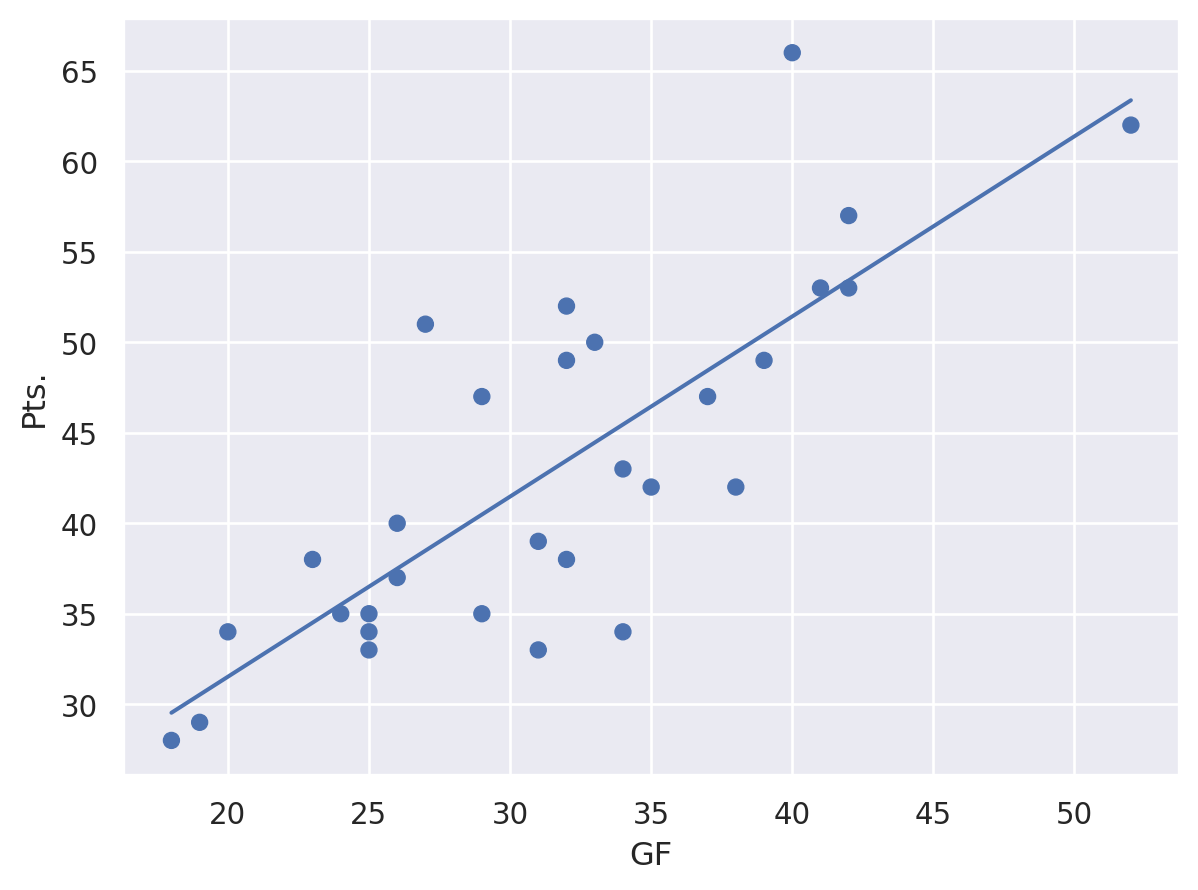

In [57]:
(
    so.Plot(tabla_posiciones, x="GF")
    .add(so.Dot(), y="Pts.")
    .add(so.Line(), so.PolyFit(1), y="Pts.")
)

## Uso de APIs

Una API (Application Programming Interface) define una sintaxis estandarízada que permite la comunicación entre nosotros (clientes) y un determinado servidor.

Generalmente, cada API tiene sus instrucciones que describen la forma de comunicarnos con sus **endpoints** para extraer la información requerida a partir de una URL

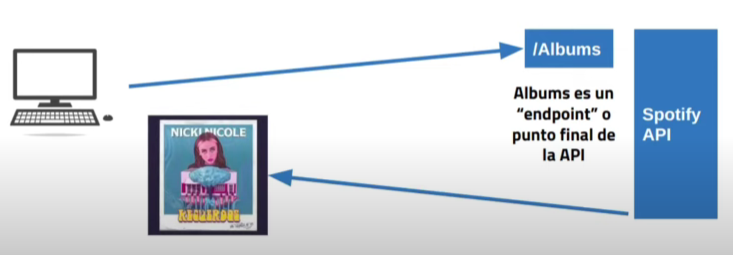
Figura extraida del curso de Gustavo Juantorena https://www.youtube.com/watch?v=yKi9-BfbfzQ&ab_channel=freeCodeCampEspa%C3%B1ol Mirenlo!

Usualmente, la respuesta de una API llega en formato *JSON*, que es un formato bastante distinto a los csv que venimos manejando.

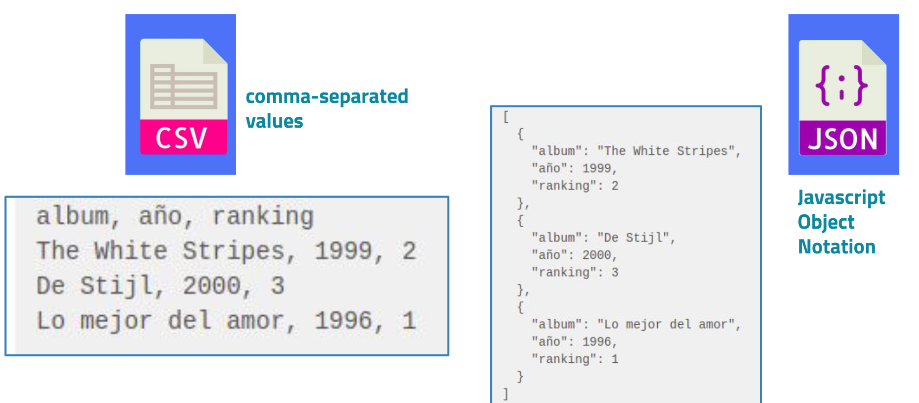
Fuente: https://www.youtube.com/watch?v=yKi9-BfbfzQ&ab_channel=freeCodeCampEspa%C3%B1ol 

## API Transporte BA - ECO BICIS

El gobierno de la Ciudad de Buenos Aires tiene una API mas o menos piola para levantar datos sobre colectivos, subtes, trenes y bicis en el ámbito de la Ciudad https://api-transporte.buenosaires.gob.ar/

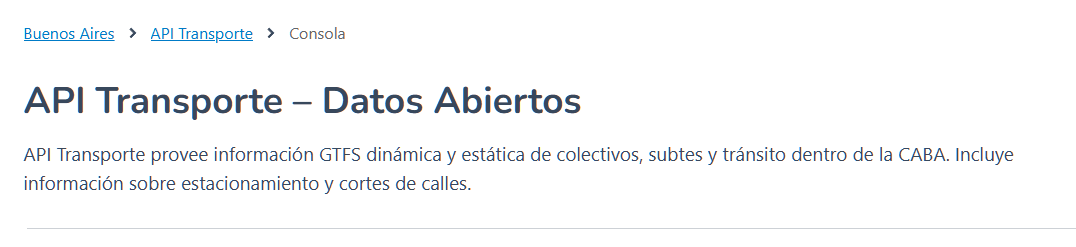

Para poder acceder a este tipo de APIs, es común tener que registrarse para obtener algún tipo de credencial. Se pueden registrar acá: https://api-transporte.buenosaires.gob.ar/registro

Ahora si, vamos a probar descargar la información sobre las estaciones de eco bici de Buenos Aires

In [58]:
link_api='https://apitransporte.buenosaires.gob.ar/ecobici/gbfs/stationInformation?'
response = requests.get(link_api)
response.status_code


401

Estamos desautorizados (?) porque no pusimos las credenciales. Para hacerlo, tenemos que incluir las mismas dentro del parámetro **params**

In [59]:

credenciales = {
    "client_id": "f3429f52737b4e019607007f7454602f",
    "client_secret": "E09120C8BC17468fBd98Bd7F37173674"
}

response = requests.get(link_api, params=credenciales)
response.status_code

200

In [60]:
estaciones_info = response.json()
estaciones_info

{'last_updated': 1770678373,
 'ttl': 1,
 'data': {'stations': [{'station_id': '2',
    'name': '002 - Retiro I',
    'physical_configuration': 'SMARTLITMAPFRAME',
    'lat': -34.59242413,
    'lon': -58.37470988999999,
    'altitude': None,
    'address': 'AV. Dr. José María Ramos Mejía 1300',
    'post_code': '11111',
    'capacity': 40,
    'is_charging_station': False,
    'rental_methods': ['KEY', 'TRANSITCARD', 'PHONE'],
    'groups': ['RETIRO'],
    'obcn': '',
    'short_name': '',
    'nearby_distance': 1000.0,
    '_ride_code_support': True,
    'rental_uris': {}},
   {'station_id': '3',
    'name': '003 - ADUANA',
    'physical_configuration': 'SMARTLITMAPFRAME',
    'lat': -34.61220714255728,
    'lon': -58.369129063788996,
    'altitude': None,
    'address': 'Av. Paseo Colón 380',
    'cross_street': '.',
    'post_code': 'C1063',
    'capacity': 28,
    'is_charging_station': False,
    'rental_methods': ['KEY', 'TRANSITCARD', 'PHONE'],
    'groups': ['MONSERRAT'],
    'n

In [61]:
estaciones_info["data"]["stations"]

[{'station_id': '2',
  'name': '002 - Retiro I',
  'physical_configuration': 'SMARTLITMAPFRAME',
  'lat': -34.59242413,
  'lon': -58.37470988999999,
  'altitude': None,
  'address': 'AV. Dr. José María Ramos Mejía 1300',
  'post_code': '11111',
  'capacity': 40,
  'is_charging_station': False,
  'rental_methods': ['KEY', 'TRANSITCARD', 'PHONE'],
  'groups': ['RETIRO'],
  'obcn': '',
  'short_name': '',
  'nearby_distance': 1000.0,
  '_ride_code_support': True,
  'rental_uris': {}},
 {'station_id': '3',
  'name': '003 - ADUANA',
  'physical_configuration': 'SMARTLITMAPFRAME',
  'lat': -34.61220714255728,
  'lon': -58.369129063788996,
  'altitude': None,
  'address': 'Av. Paseo Colón 380',
  'cross_street': '.',
  'post_code': 'C1063',
  'capacity': 28,
  'is_charging_station': False,
  'rental_methods': ['KEY', 'TRANSITCARD', 'PHONE'],
  'groups': ['MONSERRAT'],
  'nearby_distance': 1000.0,
  '_ride_code_support': True,
  'rental_uris': {}},
 {'station_id': '4',
  'name': '004 - Plaza R

In [62]:
estaciones_info_df = pd.DataFrame(estaciones_info["data"]["stations"])
estaciones_info_df = estaciones_info_df[["station_id", "name", "address", "capacity", "groups", "lat", "lon"]]
estaciones_info_df

,station_id,name,address,capacity,groups,lat,lon
0,2,002 - Retiro I,AV. Dr. José María Ramos Mejía 1300,40,[RETIRO],-34.592424,-58.374710
1,3,003 - ADUANA,Av. Paseo Colón 380,28,[MONSERRAT],-34.612207,-58.369129
2,4,004 - Plaza Roma,Av. Corrientes 100,20,[SAN NICOLAS],-34.603008,-58.368856
3,5,005 - Plaza Italia,Av. Sarmiento 2601,42,[PALERMO],-34.580550,-58.420954
4,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",20,[SAN TELMO],-34.628526,-58.369758
...,...,...,...,...,...,...,...
393,591,398 - MERCEDES,Av. Francisco Beiró 4150,16,[DEVOTO],-34.604763,-58.509574
394,593,341 - EDITORIAL PERFIL,California 2731,16,[BARRACAS],-34.648905,-58.384794
395,594,172 - UBA EXACTAS,Intendente Güiraldes 2160,20,[BELGRANO],-34.544041,-58.439077
396,596,198 - CENTRO METROPOLITANO DE DISEÑO,Algarrobo 1041,12,[],-34.654838,-58.379427


## Vamos a trabajar con algunas preguntas concretas:
1. ¿Cuál es el barrio con más estaciones?
2. ¿Cuál es el barrio con más capacidad?
3. ¿Hay una relación entre la cantidad de estaciones y la capacidad?

In [63]:
estaciones_info_df = estaciones_info_df.explode("groups")

In [64]:
estaciones_info_df["groups"].value_counts().sort_values(ascending=False).idxmax()

'PALERMO'

In [65]:
estaciones_info_df.groupby("groups")["capacity"].sum().sort_values(ascending=False).idxmax()

'PALERMO'

In [66]:
estaciones_info_df.head()

,station_id,name,address,capacity,groups,lat,lon
0,2,002 - Retiro I,AV. Dr. José María Ramos Mejía 1300,40,RETIRO,-34.592424,-58.374710
1,3,003 - ADUANA,Av. Paseo Colón 380,28,MONSERRAT,-34.612207,-58.369129
2,4,004 - Plaza Roma,Av. Corrientes 100,20,SAN NICOLAS,-34.603008,-58.368856
3,5,005 - Plaza Italia,Av. Sarmiento 2601,42,PALERMO,-34.580550,-58.420954
4,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",20,SAN TELMO,-34.628526,-58.369758


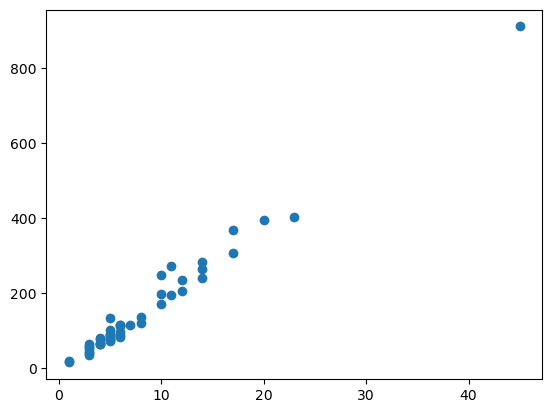

In [67]:
estaciones_barrio = estaciones_info_df.groupby("groups").size()
capacidad_barrio = estaciones_info_df.groupby("groups")["capacity"].sum()
plt.scatter(estaciones_barrio, capacidad_barrio)

## Vamos a analizar la información actual (tiempo real) de las estaciones

Algo lindo sería analizar si hay estaciones o barrios que les vendría bien tener más bicis. Para eso, vamos a tener que ir al endpoint https://apitransporte.buenosaires.gob.ar/ecobici/gbfs/stationStatus?


In [68]:

link_api='https://apitransporte.buenosaires.gob.ar/ecobici/gbfs/stationStatus?'


response = requests.get(link_api, params= credenciales)
estaciones_estado = response.json()
estaciones_estado

{'last_updated': 1770678376,
 'ttl': 3,
 'data': {'stations': [{'station_id': '2',
    'num_bikes_available': 3,
    'num_bikes_available_types': {'mechanical': 3, 'ebike': 0},
    'num_bikes_disabled': 1,
    'num_docks_available': 36,
    'num_docks_disabled': 0,
    'last_reported': 1770678296,
    'is_charging_station': False,
    'status': 'IN_SERVICE',
    'is_installed': 1,
    'is_renting': 1,
    'is_returning': 1,
    'traffic': None},
   {'station_id': '3',
    'num_bikes_available': 0,
    'num_bikes_available_types': {'mechanical': 0, 'ebike': 0},
    'num_bikes_disabled': 0,
    'num_docks_available': 28,
    'num_docks_disabled': 0,
    'last_reported': 1770678296,
    'is_charging_station': False,
    'status': 'IN_SERVICE',
    'is_installed': 1,
    'is_renting': 1,
    'is_returning': 1,
    'traffic': None},
   {'station_id': '4',
    'num_bikes_available': 0,
    'num_bikes_available_types': {'mechanical': 0, 'ebike': 0},
    'num_bikes_disabled': 4,
    'num_docks

In [71]:
estaciones_estado_df = pd.DataFrame(estaciones_estado["data"]["stations"])
estaciones_estado_df

,station_id,num_bikes_available,num_bikes_available_types,num_bikes_disabled,num_docks_available,num_docks_disabled,last_reported,is_charging_station,status,is_installed,is_renting,is_returning,traffic
0,2,3,"{'mechanical': 3, 'ebike': 0}",1,36,0,1770678296,False,IN_SERVICE,1,1,1,None
1,3,0,"{'mechanical': 0, 'ebike': 0}",0,28,0,1770678296,False,IN_SERVICE,1,1,1,None
2,4,0,"{'mechanical': 0, 'ebike': 0}",4,16,0,1770678325,False,IN_SERVICE,1,1,1,None
3,5,4,"{'mechanical': 4, 'ebike': 0}",4,34,0,1770678199,False,IN_SERVICE,1,1,1,None
4,6,11,"{'mechanical': 11, 'ebike': 0}",4,5,0,1770678198,False,IN_SERVICE,1,1,1,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,591,3,"{'mechanical': 3, 'ebike': 0}",0,13,0,1770678307,False,IN_SERVICE,1,1,1,None
394,593,6,"{'mechanical': 6, 'ebike': 0}",3,7,0,1770678293,False,IN_SERVICE,1,1,1,None
395,594,0,"{'mechanical': 0, 'ebike': 0}",0,20,0,1770678251,False,IN_SERVICE,1,1,1,None
396,596,12,"{'mechanical': 12, 'ebike': 0}",0,0,0,1770678201,False,IN_SERVICE,1,1,1,None


vamos a ver que usando lo que hicimos antes ["data"]["stations"] no terminamos de obtener un dataframe como antes

Vamos a responder las siguientes preguntas:
1. ¿Cómo calcularías la disponibilidad de bicis de una estación? Es decir, ¿Cuán usada es una estación?
2. ¿Las estaciones con más capacidad son las más usadas?
3. ¿Cómo podríamos identificar barrios con estaciones que sean poco usadas?

In [80]:
# 1
estaciones_estado_df["capacidad_actual"] = estaciones_estado_df["num_bikes_available"] + estaciones_estado_df["num_docks_available"]
estaciones_estado_df["disponibilidad"] = estaciones_estado_df["num_bikes_available"] / estaciones_estado_df["capacidad_actual"]
estaciones_estado_df["disponibilidad"]

0      0.076923
1      0.000000
2      0.000000
3      0.105263
4      0.687500
         ...   
393    0.187500
394    0.461538
395    0.000000
396    1.000000
397    0.153846
Name: disponibilidad, Length: 398, dtype: float64

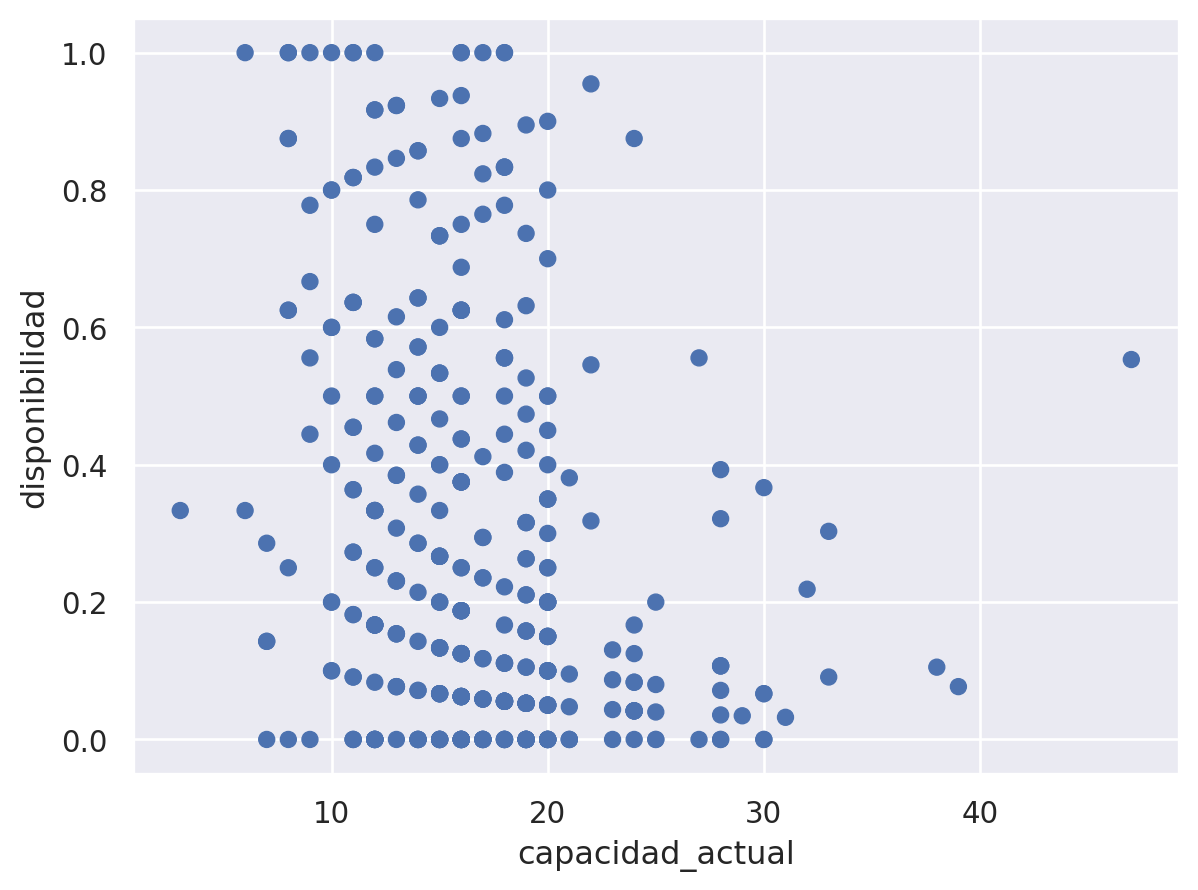

In [82]:
# 2
(
    so.Plot(data=estaciones_estado_df, x="capacidad_actual", y="disponibilidad")
    .add(so.Dot())
)

In [91]:
# 3
estaciones_estado_df = pd.merge(estaciones_estado_df, estaciones_info_df[["station_id", "groups"]], on="station_id")
estaciones_estado_df

MergeError: Passing 'suffixes' which cause duplicate columns {'groups_x'} is not allowed.

In [92]:
estaciones_estado_df.groupby("groups")["disponibilidad"].mean().sort_values(ascending=False)

groups
LINIERS                0.911600
PARQUE AVELLANEDA      0.838810
VELEZ SARFIELD         0.791667
PARQUE CHACABUCO       0.786987
VILLA LURO             0.755381
BARRACAS               0.733026
MATADEROS              0.664338
NUEVA POMPEYA          0.630682
VILLA REAL             0.625000
VILLA SOLDATI          0.613596
VILLA GENERAL MITRE    0.596726
VERSALLES              0.578958
CABALLITO              0.568140
BOCA                   0.546002
VILLA PUYRREDON        0.475595
AGRONOMIA              0.463889
VILLA LUGANO           0.455556
FLORES                 0.455317
PATERNAL               0.435155
MONTE CASTRO           0.423310
PARQUE PATRICIOS       0.404527
VILLA RIACHUELO        0.400000
VILLA DEVOTO           0.339624
VILLA SANTA RITA       0.334609
ZONA 1                 0.286200
PARQUE CHAS            0.285307
SAAVEDRA               0.285248
VILLA DEL PARQUE       0.255000
Nuñez                  0.246646
CONSTITUCION           0.234555
VILLA URQUIZA          0.216638
F

Una cosa importante para comentar es que las apis son básicamente páginas web que reciben parámetros. No es necesario tener programas especiales ni nada raro para conectarse 

Por ejemplo, para acceder a los datos de la información de estaciones de eco bici, podríamos entrar en esta web: https://apitransporte.buenosaires.gob.ar/ecobici/gbfs/stationInformation?client_id=f3429f52737b4e019607007f7454602f&client_secret=E09120C8BC17468fBd98Bd7F37173674 que tiene el cliente y el secret metido en el medio.

Sin embargo, acceder mediante código es clave cuando queremos volver  más reproducible o automatizable el flujo de trabajo.
Por ejemplo, este repo actualiza cada una hora la info de las estaciones de ecobici de ciudad universitaria https://github.com/FedeGiovannetti/Eco_bici_Ciudad_Universitaria

Si alguien quiere sumarse a hacer algo con esta idea super simple (por ej, poner a disposición algun dashboard con info de las estaciones de Ciudad Universitaria) me avisan giovannettipsi@gmail.com


## API wrappers

Finalmente, existen los API wrappers, que son librerías que actúa como una capa de abstracción sobre una API. Su propósito es facilitar el acceso a la API sin que el usuario tenga que hacer llamadas HTTP manuales. Wikipedia por ejemplo tiene este tipo de wrappers. También hay librerias como https://github.com/federicorabanos/LanusStats/tree/main que no son APIs pero funcionan un poco como si lo fueran ya que scrappean las páginas de forma muy eficiente.